# Laboratorio 8 – Máquinas Vectoriales de Soporte 

In [2]:
import pyreadr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix, classification_report, accuracy_score,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
plt.style.use('ggplot')

In [3]:
# Cargar el dataset desde el archivo RData de lab7
result = pyreadr.read_r('../lab7/laboratorio-7-Regresi-n-log-stica/listings.RData')
data = result['listings']

print(f'Dimensiones originales: {data.shape}')
data.head(3)

Dimensiones originales: (171748, 80)


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"


In [4]:
# ── Limpieza de la variable precio ──────────────────────────────────────────
data['price'] = (data['price']
                 .astype(str)
                 .str.replace('$', '', regex=False)
                 .str.replace(',', '', regex=False))
data['price'] = pd.to_numeric(data['price'], errors='coerce')
data = data.dropna(subset=['price'])
data = data[data['price'] > 0]  # eliminar precios en 0

# ── Variable respuesta: categoría de precio (3 clases iguales por cuantil) ──
data['price_cat'] = pd.qcut(data['price'], 3, labels=['barata', 'media', 'cara'])

print('Distribución de categorías de precio:')
print(data['price_cat'].value_counts())
print(f'\nRangos de precio por categoría:')
print(data.groupby('price_cat')['price'].agg(['min', 'max']))

Distribución de categorías de precio:
price_cat
barata    25689
cara      25404
media     25153
Name: count, dtype: int64

Rangos de precio por categoría:
             min      max
price_cat                
barata       8.0    143.0
media      144.0    268.0
cara       269.0  50123.0


In [5]:
# ── Mismas 7 variables predictoras que en labs anteriores ───────────────────
FEATURES = ['accommodates', 'bathrooms', 'bedrooms', 'beds',
            'minimum_nights', 'number_of_reviews', 'review_scores_rating']

df = data[FEATURES + ['price_cat']].dropna()
print(f'Dataset final (sin NaN): {df.shape}')

X = df[FEATURES]
y = df['price_cat']

# ── Misma partición 70/30 con random_state=42 ───────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f'Entrenamiento: {X_train.shape[0]} filas')
print(f'Prueba       : {X_test.shape[0]} filas')
print('\nDistribución y_train:')
print(y_train.value_counts())
print('\nDistribución y_test:')
print(y_test.value_counts())

Dataset final (sin NaN): (62722, 8)
Entrenamiento: 43905 filas
Prueba       : 18817 filas

Distribución y_train:
price_cat
barata    15872
media     14860
cara      13173
Name: count, dtype: int64

Distribución y_test:
price_cat
barata    6688
media     6364
cara      5765
Name: count, dtype: int64


---
## Exploración de los datos y transformaciones necesarias para SVM


In [6]:
# ── Estadísticas descriptivas antes de escalar ──────────────────────────────
print('Estadísticas descriptivas (X_train):')
X_train.describe().round(2)

Estadísticas descriptivas (X_train):


,accommodates,bathrooms,minimum_nights,number_of_reviews,review_scores_rating
count,43905.00,43905.00,43905.00,43905.00,43905.00
mean,4.83,1.59,7.38,66.23,4.80
std,2.94,0.92,16.73,102.16,0.33
min,1.00,0.00,1.00,1.00,1.00
25%,2.00,1.00,1.00,6.00,4.75
50%,4.00,1.00,2.00,27.00,4.89
75%,6.00,2.00,4.00,83.00,5.00
max,16.00,17.00,365.00,1592.00,5.00


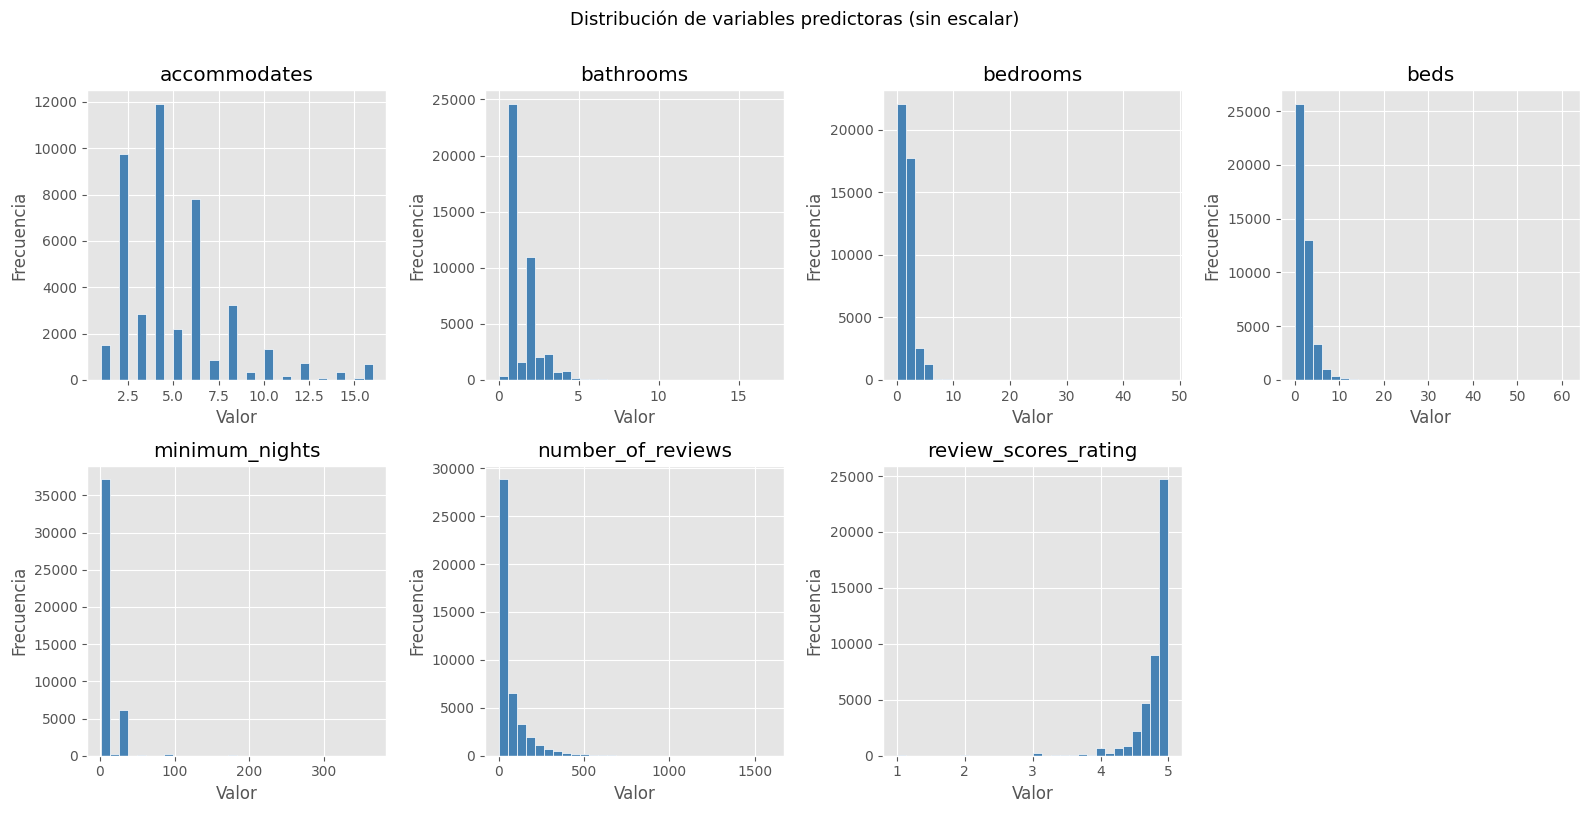

In [7]:
# ── Distribución de cada variable predictora ─────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(FEATURES):
    axes[i].hist(X_train[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frecuencia')
axes[-1].set_visible(False)
plt.suptitle('Distribución de variables predictoras (sin escalar)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

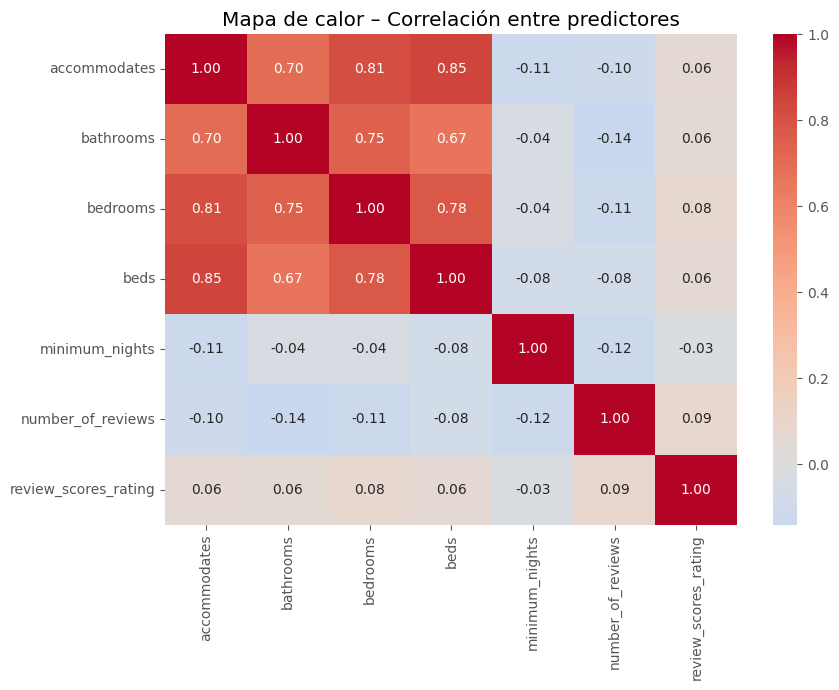


Observaciones:
  • accommodates, bedrooms y beds presentan alta correlación entre sí (multicolinealidad).
  • minimum_nights y number_of_reviews tienen distribuciones muy sesgadas (cola larga).
  • Las escalas varían considerablemente: review_scores_rating va de 0–5 y
    number_of_reviews puede superar 1000.

Transformaciones requeridas para SVM:
  1. Estandarización (StandardScaler): media=0, desv. estándar=1 para cada columna.
     El scaler se ajusta SOLO en el conjunto de entrenamiento y se aplica a ambos
     conjuntos para evitar data leakage.
  2. No se requieren variables dummy porque todos los predictores son numéricos.
  3. No se eliminan outliers para conservar la misma base de datos de labs anteriores,
     pero el escalado reduce su impacto relativo.



In [8]:
# ── Correlación entre predictores ───────────────────────────────────────────
plt.figure(figsize=(9, 7))
sns.heatmap(X_train.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Mapa de calor – Correlación entre predictores')
plt.tight_layout()
plt.show()

print("""
Observaciones:
  • accommodates, bedrooms y beds presentan alta correlación entre sí (multicolinealidad).
  • minimum_nights y number_of_reviews tienen distribuciones muy sesgadas (cola larga).
  • Las escalas varían considerablemente: review_scores_rating va de 0–5 y
    number_of_reviews puede superar 1000.

Transformaciones requeridas para SVM:
  1. Estandarización (StandardScaler): media=0, desv. estándar=1 para cada columna.
     El scaler se ajusta SOLO en el conjunto de entrenamiento y se aplica a ambos
     conjuntos para evitar data leakage.
  2. No se requieren variables dummy porque todos los predictores son numéricos.
  3. No se eliminan outliers para conservar la misma base de datos de labs anteriores,
     pero el escalado reduce su impacto relativo.
""")

In [9]:
# ── Estandarización ──────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)   # ajuste + transformación en train
X_test_sc  = scaler.transform(X_test)        # solo transformación en test

print('Media por columna después de escalar (train):', X_train_sc.mean(axis=0).round(4))
print('Desv. estándar después de escalar (train)   :', X_train_sc.std(axis=0).round(4))

Media por columna después de escalar (train): [ 0.  0. -0.  0. -0.  0. -0.]
Desv. estándar después de escalar (train)   : [1. 1. 1. 1. 1. 1. 1.]


---
## 3. Variable respuesta: categoría de precio


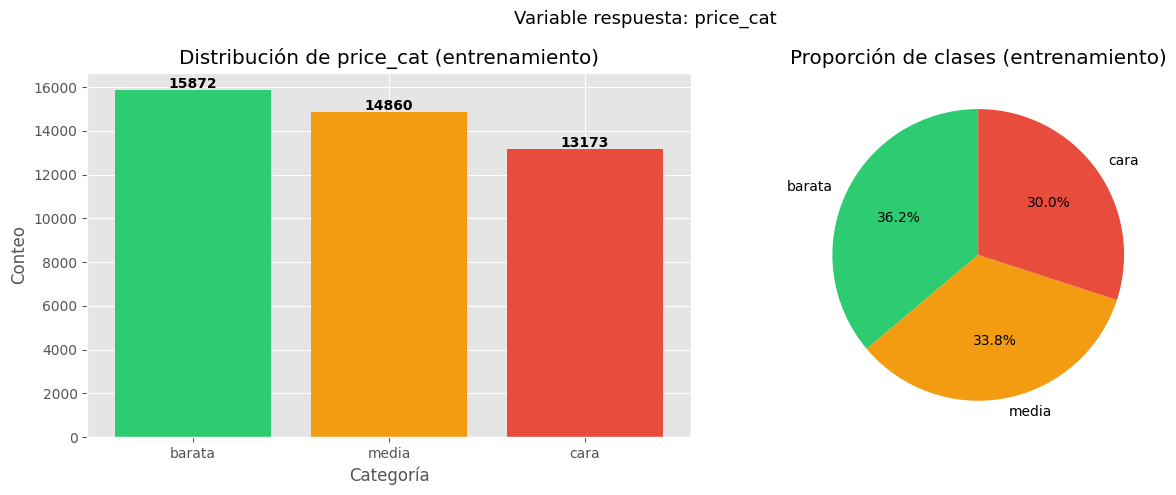

In [10]:
# Visualización de la variable respuesta
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
counts = y_train.value_counts()
axes[0].bar(counts.index, counts.values, color=['#2ecc71', '#f39c12', '#e74c3c'])
axes[0].set_title('Distribución de price_cat (entrenamiento)')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Conteo')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pastel
axes[1].pie(counts.values, labels=counts.index,
            colors=['#2ecc71', '#f39c12', '#e74c3c'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporción de clases (entrenamiento)')

plt.suptitle('Variable respuesta: price_cat', fontsize=13)
plt.tight_layout()
plt.show()

---
## 4. Modelos SVM con diferentes kernels y parámetros

Se generan **cuatro modelos** con distintos kernels y configuraciones de hiperparámetros:

| Modelo | Kernel | C | Gamma / d |
|--------|--------|---|----------|
| SVM1   | Lineal | 1.0 | — |
| SVM2   | RBF    | 1.0 | scale |
| SVM3   | RBF    | 10.0 | 0.1 |
| SVM4   | Polinomial (d=3) | 1.0 | scale |



In [12]:
# Diccionario de configuraciones
configs = {
    'SVM1_lineal':    dict(kernel='linear',  C=1.0),
    'SVM2_rbf_C1':    dict(kernel='rbf',     C=1.0,  gamma='scale'),
    'SVM3_rbf_C10':   dict(kernel='rbf',     C=10.0, gamma=0.1),
    'SVM4_poly_d3':   dict(kernel='poly',    C=1.0,  gamma='scale', degree=3),
}

modelos   = {}
tiempos   = {}
acc_train = {}
acc_test  = {}

for nombre, params in configs.items():
    print(f'Entrenando {nombre} ...', end=' ')
    svm = SVC(**params, random_state=42, probability=True)
    t0 = time.time()
    svm.fit(X_train_sc, y_train)
    elapsed = time.time() - t0

    modelos[nombre]   = svm
    tiempos[nombre]   = round(elapsed, 2)
    acc_train[nombre] = round(accuracy_score(y_train, svm.predict(X_train_sc)), 4)
    acc_test[nombre]  = round(accuracy_score(y_test,  svm.predict(X_test_sc)),  4)

    print(f'listo en {elapsed:.1f}s  |  acc_train={acc_train[nombre]}  acc_test={acc_test[nombre]}')

Entrenando SVM1_lineal ... listo en 216.1s  |  acc_train=0.573  acc_test=0.5727
Entrenando SVM2_rbf_C1 ... listo en 540.4s  |  acc_train=0.6049  acc_test=0.602
Entrenando SVM3_rbf_C10 ... listo en 258.5s  |  acc_train=0.6081  acc_test=0.6021
Entrenando SVM4_poly_d3 ... listo en 511.4s  |  acc_train=0.5554  acc_test=0.5519


### 4a. Tuneo automático del mejor kernel (RBF) con GridSearchCV

In [ ]:
# GridSearchCV sobre kernel RBF con validación cruzada de 5 folds
param_grid = {
    'C':     [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1]
}

gs = GridSearchCV(
    SVC(kernel='rbf', random_state=42, probability=True),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print('Ejecutando GridSearchCV (puede tardar varios minutos)...')
t0 = time.time()
gs.fit(X_train_sc, y_train)
gs_time = time.time() - t0

print(f'\nTiempo total GridSearch: {gs_time:.1f}s')
print(f'Mejores parámetros: {gs.best_params_}')
print(f'Mejor accuracy CV : {gs.best_score_:.4f}')

Ejecutando GridSearchCV (puede tardar varios minutos)...
Fitting 5 folds for each of 16 candidates, totalling 80 fits


In [ ]:
# Agregar el modelo tuneado a la colección
svm_gs = gs.best_estimator_
nombre_gs = 'SVM5_rbf_tuneado'
t0 = time.time()
svm_gs.fit(X_train_sc, y_train)  # re-entrenar con todos los datos de train
modelos[nombre_gs]   = svm_gs
tiempos[nombre_gs]   = round(time.time() - t0, 2)
acc_train[nombre_gs] = round(accuracy_score(y_train, svm_gs.predict(X_train_sc)), 4)
acc_test[nombre_gs]  = round(accuracy_score(y_test,  svm_gs.predict(X_test_sc)),  4)

print(f'SVM5 (tuneado): acc_train={acc_train[nombre_gs]}  acc_test={acc_test[nombre_gs]}')

---
## 5. Predicciones con cada modelo

In [ ]:
predicciones = {}
for nombre, modelo in modelos.items():
    predicciones[nombre] = modelo.predict(X_test_sc)

# Vista de muestra de predicciones del modelo tuneado
pred_df = pd.DataFrame({
    'Real': y_test.values[:15],
    'SVM5_tuneado': predicciones['SVM5_rbf_tuneado'][:15]
})
print('Muestra de predicciones vs valores reales (primeras 15 filas):')
print(pred_df.to_string(index=False))

---
## 6. Matrices de confusión

In [ ]:
clases = ['barata', 'media', 'cara']

fig, axes = plt.subplots(2, 3, figsize=(18, 11))
axes = axes.flatten()

for i, (nombre, preds) in enumerate(predicciones.items()):
    cm = confusion_matrix(y_test, preds, labels=clases)
    disp = ConfusionMatrixDisplay(cm, display_labels=clases)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{nombre}\nacc={acc_test[nombre]}', fontsize=11)

# Ocultar eje sobrante
axes[-1].set_visible(False)
plt.suptitle('Matrices de Confusión – Conjunto de Prueba', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Reporte detallado por modelo
for nombre, preds in predicciones.items():
    print(f'{'='*60}')
    print(f'  {nombre}')
    print(f'{'='*60}')
    print(classification_report(y_test, preds, target_names=clases))

In [ ]:
# Tabla resumen de métricas
from sklearn.metrics import f1_score, precision_score, recall_score

resumen = []
for nombre, preds in predicciones.items():
    resumen.append({
        'Modelo'      : nombre,
        'Kernel'      : modelos[nombre].kernel,
        'Acc_Train'   : acc_train[nombre],
        'Acc_Test'    : acc_test[nombre],
        'F1_macro'    : round(f1_score(y_test, preds, average='macro'), 4),
        'Precision'   : round(precision_score(y_test, preds, average='macro'), 4),
        'Recall'      : round(recall_score(y_test, preds, average='macro'), 4),
        'Tiempo_s'    : tiempos[nombre],
    })

df_resumen = pd.DataFrame(resumen)
print('\n=== Resumen de métricas por modelo ===')
print(df_resumen.to_string(index=False))

---
## 7. Análisis de sobreajuste y desajuste

Para determinar si un modelo está sobreajustado o desajustado en clasificación se comparan las métricas de entrenamiento y prueba:

- Si **Acc_Train ≫ Acc_Test** → sobreajuste: el modelo memorizó el training set.
- Si **Acc_Train ≈ Acc_Test ≈ bajo** → desajuste: el modelo es demasiado simple.
- Si **Acc_Train ≈ Acc_Test ≈ alto** → buen ajuste generalizable.

In [ ]:
# ── Gráfico train vs test accuracy por modelo ────────────────────────────────
nombres = list(acc_train.keys())
train_vals = [acc_train[n] for n in nombres]
test_vals  = [acc_test[n]  for n in nombres]

x = np.arange(len(nombres))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, train_vals, width, label='Accuracy Train', color='#3498db')
bars2 = ax.bar(x + width/2, test_vals,  width, label='Accuracy Test',  color='#e74c3c')

ax.set_xlabel('Modelo')
ax.set_ylabel('Accuracy')
ax.set_title('Comparación Accuracy Train vs Test por Modelo SVM')
ax.set_xticks(x)
ax.set_xticklabels(nombres, rotation=20, ha='right')
ax.set_ylim(0.4, 1.05)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()

In [ ]:
# ── Tabla de brecha train-test ────────────────────────────────────────────────
df_overfit = df_resumen[['Modelo', 'Acc_Train', 'Acc_Test']].copy()
df_overfit['Brecha (Train-Test)'] = (df_overfit['Acc_Train'] - df_overfit['Acc_Test']).round(4)

def clasificar_ajuste(brecha, acc_test):
    if brecha > 0.05:
        return 'Sobreajuste'
    elif acc_test < 0.55:
        return 'Desajuste'
    else:
        return 'Buen ajuste'

df_overfit['Diagnóstico'] = df_overfit.apply(
    lambda r: clasificar_ajuste(r['Brecha (Train-Test)'], r['Acc_Test']), axis=1
)

print('\n=== Diagnóstico de ajuste por modelo ===')
print(df_overfit.to_string(index=False))

In [ ]:
print("""
Análisis de sobreajuste / desajuste:
─────────────────────────────────────────────────────────────────────
• SVM1 (Lineal, C=1): Kernel lineal con margen amplio → modelo simple,
  bajo riesgo de sobreajuste. Si la brecha es pequeña y el accuracy
  es razonable, indica buen ajuste generalizable.

• SVM2 (RBF, C=1, gamma=scale): Configuración balanceada. Gamma 'scale'
  adapta el radio de influencia al número de features y varianza de X.

• SVM3 (RBF, C=10, gamma=0.1): C alto reduce el margen → más puntos de
  soporte, más ajuste al entrenamiento → mayor riesgo de sobreajuste.
  Si Acc_Train >> Acc_Test, confirma sobreajuste.

• SVM4 (Poly, d=3): El kernel polinomial de grado 3 puede memorizar
  patrones no lineales complejos; con C=1 el riesgo es moderado.

• SVM5 (RBF tuneado con GridSearchCV): Parámetros óptimos según CV de
  5 folds; es el modelo con mejor balance bias-varianza esperado.

Estrategias para manejar sobreajuste en SVM:
  1. Reducir C (aumentar regularización) para ampliar el margen.
  2. Reducir gamma (kernels RBF/poly) para suavizar la frontera.
  3. Usar validación cruzada (CV) para seleccionar hiperparámetros.
  4. Aumentar el tamaño del conjunto de entrenamiento.
  5. Aplicar reducción de dimensionalidad si hay multicolinealidad severa.

Estrategias para manejar desajuste:
  1. Aumentar C (reducir regularización).
  2. Cambiar a un kernel más expresivo (RBF o poly).
  3. Agregar nuevas variables o transformaciones (e.g. interacciones).
─────────────────────────────────────────────────────────────────────
""")